# 🚀 Análisis de Estrategia de Precios y Satisfacción en Amazon India
**Autor:** Franco Salinas Huerta 
**Dataset:** Amazon Sales Dataset (+1,400 productos)

### 🎯 Objetivo del Proyecto
Este proyecto combina un proceso completo de **ETL (Extract, Transform, Load)** con un **Análisis Exploratorio de Datos (EDA)**. El fin es identificar patrones entre los descuentos aplicados por Amazon y la percepción de calidad de los usuarios, así como entender la jerarquía de precios en las categorías líderes.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("amazon.csv")

In [3]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 1465, Columnas: 16


In [4]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [6]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [7]:
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 0


In [8]:
df.columns.to_list()

['product_id',
 'product_name',
 'category',
 'discounted_price',
 'actual_price',
 'discount_percentage',
 'rating',
 'rating_count',
 'about_product',
 'user_id',
 'user_name',
 'review_id',
 'review_title',
 'review_content',
 'img_link',
 'product_link']

## 🛠️ Fase 1: ETL (Limpieza y Transformación)
Los datos brutos presentan desafíos técnicos que deben resolverse antes del análisis:
* **Formato de Moneda:** Los precios contienen el símbolo `₹` y comas, lo que impide cálculos numéricos.
* **Tipos de Datos:** La columna `rating` contiene caracteres especiales que deben normalizarse.
* **Categorización:** Las categorías están anidadas por tuberías (`|`), por lo que extraeremos la "Categoría Principal" para una mejor visualización.

In [9]:
df['discounted_price'] = pd.to_numeric(df['discounted_price'].str.replace(r'[^\d.-]','',regex=True))
df['actual_price'] = pd.to_numeric(df['actual_price'].str.replace(r'[^\d.-]','',regex=True))
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'].str.replace(r'[^\d.-]','',regex=True))
df['rating_count'] = pd.to_numeric(df['rating_count'].str.replace(',', '', regex=False), errors='coerce')
df['rating'] = pd.to_numeric(df['rating'].str.replace(',', '', regex=False), errors='coerce')
df['category'] = df['category'].str.replace('|', ' > ', regex=False)
df['main_category'] = df['category'].str.split('>').str[0]
df = df.dropna()

In [10]:
errores_logicos = df[df['discounted_price'] > df['actual_price']]
print(f"Filas con errores de lógica: {len(errores_logicos)}")

Filas con errores de lógica: 0


In [11]:
def obtener_outliers_loc(df, columna):
    # 1. Calcular estadísticos
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # 2. Crear la máscara booleana
    mascara = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    
    # 3. Usar .loc para filtrar y devolver el resultado
    columnas_a_mostrar = ['product_name', columna]
    
    return df.loc[mascara, columnas_a_mostrar]


print("--- Outliers de Actual Price ---")
outliers_actual = obtener_outliers_loc(df, 'actual_price')
print(outliers_actual.head())

print("\n--- Outliers de Discount Price ---")
outliers_discount = obtener_outliers_loc(df, 'discounted_price')
print(outliers_discount.head())

--- Outliers de Actual Price ---
                                         product_name  actual_price
16  MI 80 cm (32 inches) 5A Series HD Ready Smart ...       24999.0
19  LG 80 cm (32 inches) HD Ready Smart LED TV 32L...       21990.0
22  Samsung 80 cm (32 Inches) Wondertainment Serie...       22900.0
24  Acer 80 cm (32 inches) I Series HD Ready Andro...       19990.0
26  OnePlus 80 cm (32 inches) Y Series HD Ready LE...       19999.0

--- Outliers de Discount Price ---
                                         product_name  discounted_price
16  MI 80 cm (32 inches) 5A Series HD Ready Smart ...           13999.0
19  LG 80 cm (32 inches) HD Ready Smart LED TV 32L...           13490.0
22  Samsung 80 cm (32 Inches) Wondertainment Serie...           13490.0
24  Acer 80 cm (32 inches) I Series HD Ready Andro...           11499.0
26  OnePlus 80 cm (32 inches) Y Series HD Ready LE...           14999.0


## 📊 Fase 2: Análisis Exploratorio de Datos (EDA)

### 1. ¿Qué categorías tienen los clientes más satisfechos?
Utilizamos un **Lollipop Chart** para observar el rating promedio por categoría. A diferencia de un gráfico de barras tradicional, este estilo reduce la carga visual y permite comparar métricas con mayor precisión.

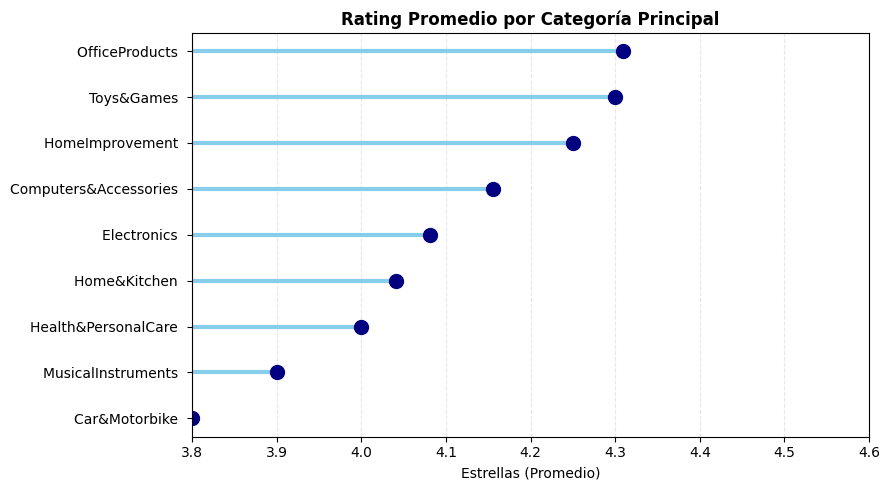

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
df_rating = df.groupby('main_category')['rating'].mean().sort_values()

plt.hlines(y=df_rating.index, xmin=3.8, xmax=df_rating.values, color='skyblue', linewidth=3)
plt.plot(df_rating.values, df_rating.index, "o", markersize=10, color='navy')

plt.title('Rating Promedio por Categoría Principal', fontweight='bold')
plt.xlabel('Estrellas (Promedio)')
plt.xlim(3.8, 4.6)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Observamos que la mayoría de las categorías principales en Amazon se mantienen en un rango de 4.0 a 4.3 estrellas. Sorprendentemente, categorías como Office Products suelen tener una consistencia de satisfacción mayor que Electronics, que presenta más variabilidad.

### 2. ¿Afectan los grandes descuentos a la valoración del producto?
Existe la hipótesis de que los productos con descuentos extremos (liquidación) podrían ser de menor calidad. Utilizaremos un **Gráfico de Regresión** para ver si existe una correlación real entre el `% de descuento` y las `estrellas` otorgadas por los compradores.

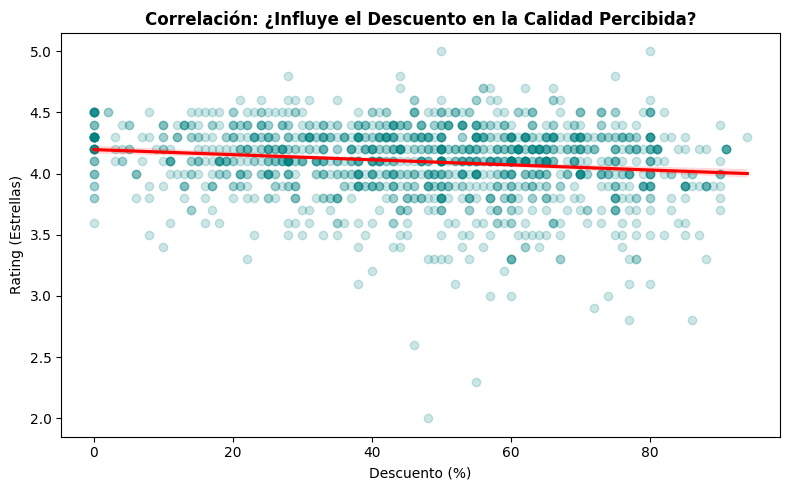

In [13]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='discount_percentage', y='rating', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Correlación: ¿Influye el Descuento en la Calidad Percibida?', fontweight='bold')
plt.xlabel('Descuento (%)')
plt.ylabel('Rating (Estrellas)')
plt.tight_layout()
plt.show()

**Insight:** La línea de tendencia es prácticamente horizontal. Esto demuestra que en el marketplace de Amazon India, un descuento alto **no es sinónimo de baja calidad**. Los usuarios valoran positivamente los productos independientemente de la rebaja aplicada.

### 3. Matriz de Valor: Precio Promedio vs. Calidad
Para entender el posicionamiento de cada sector, comparamos el precio promedio de venta frente al rating promedio. Esto nos permite identificar categorías **"Value for Money"** (bajo precio, alto rating) frente a categorías **"Premium"**.

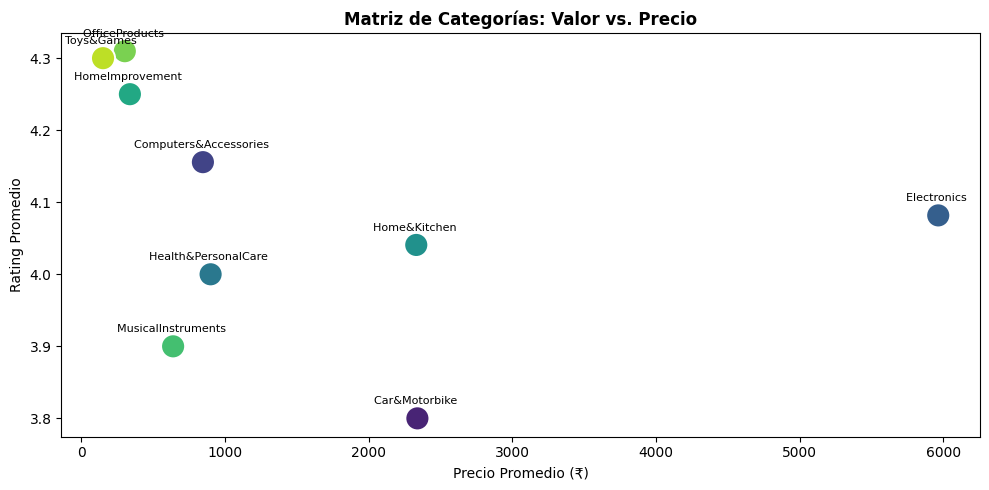

In [14]:
cat_agg = df.groupby('main_category').agg({'discounted_price': 'mean', 'rating': 'mean'}).reset_index()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=cat_agg, x='discounted_price', y='rating', hue='main_category', s=300, palette='viridis')

for i in range(cat_agg.shape[0]):
    plt.text(cat_agg.discounted_price[i], cat_agg.rating[i]+0.02, cat_agg.main_category[i], fontsize=8, ha='center')

plt.title('Matriz de Categorías: Valor vs. Precio', fontweight='bold')
plt.xlabel('Precio Promedio (₹)')
plt.ylabel('Rating Promedio')
plt.legend([],[], frameon=False) # Quitar leyenda para limpiar
plt.tight_layout()
plt.show()

**Insight:** Existe un equilibrio competitivo. Categorías como *Home & Kitchen* ofrecen una excelente relación calidad-precio, mientras que *Electronics* se desplaza hacia precios más altos manteniendo estándares de calidad similares.

### 4. Variabilidad de Precios en el Top 5 de Categorías
¿Son los precios constantes o hay una gran dispersión? Usamos **Boxplots** para visualizar los cuartiles de precios. Nota: Se han filtrado los *outliers* extremos para observar mejor el comportamiento del grueso del mercado (el "corazón" de las ventas).

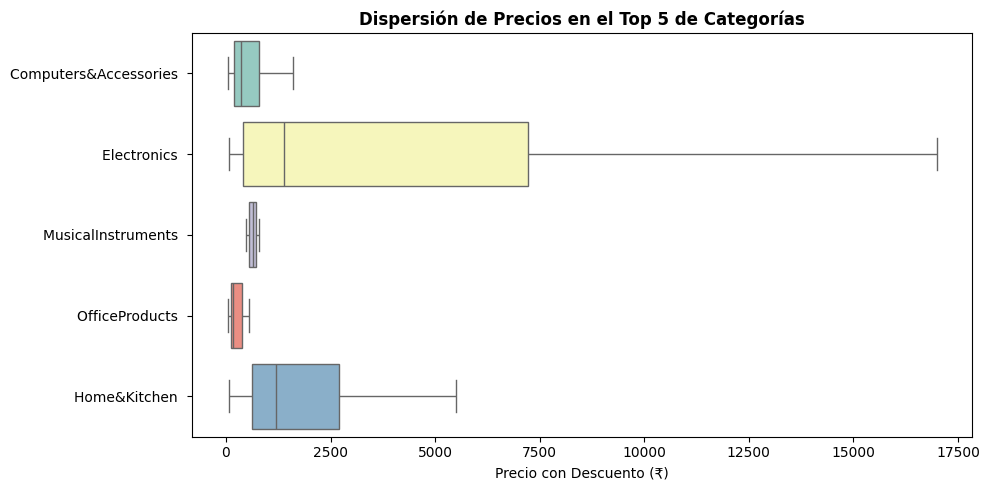

In [15]:
top_5_cats = df['main_category'].value_counts().head(5).index
df_top = df[df['main_category'].isin(top_5_cats)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_top, x='discounted_price', y='main_category', palette="Set3", showfliers=False)

plt.title('Dispersión de Precios en el Top 5 de Categorías', fontweight='bold')
plt.xlabel('Precio con Descuento (₹)')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insight:** Al eliminar valores atípicos, vemos que el grueso del mercado compite en un rango estrecho (entre ₹500 y ₹2,500). Esto indica que Amazon es un mercado de volumen donde el precio es un factor de decisión crítico y muy estandarizado.

✅ Imagen 'dashboard_amazon.png' guardada. ¡Lista para tu post!


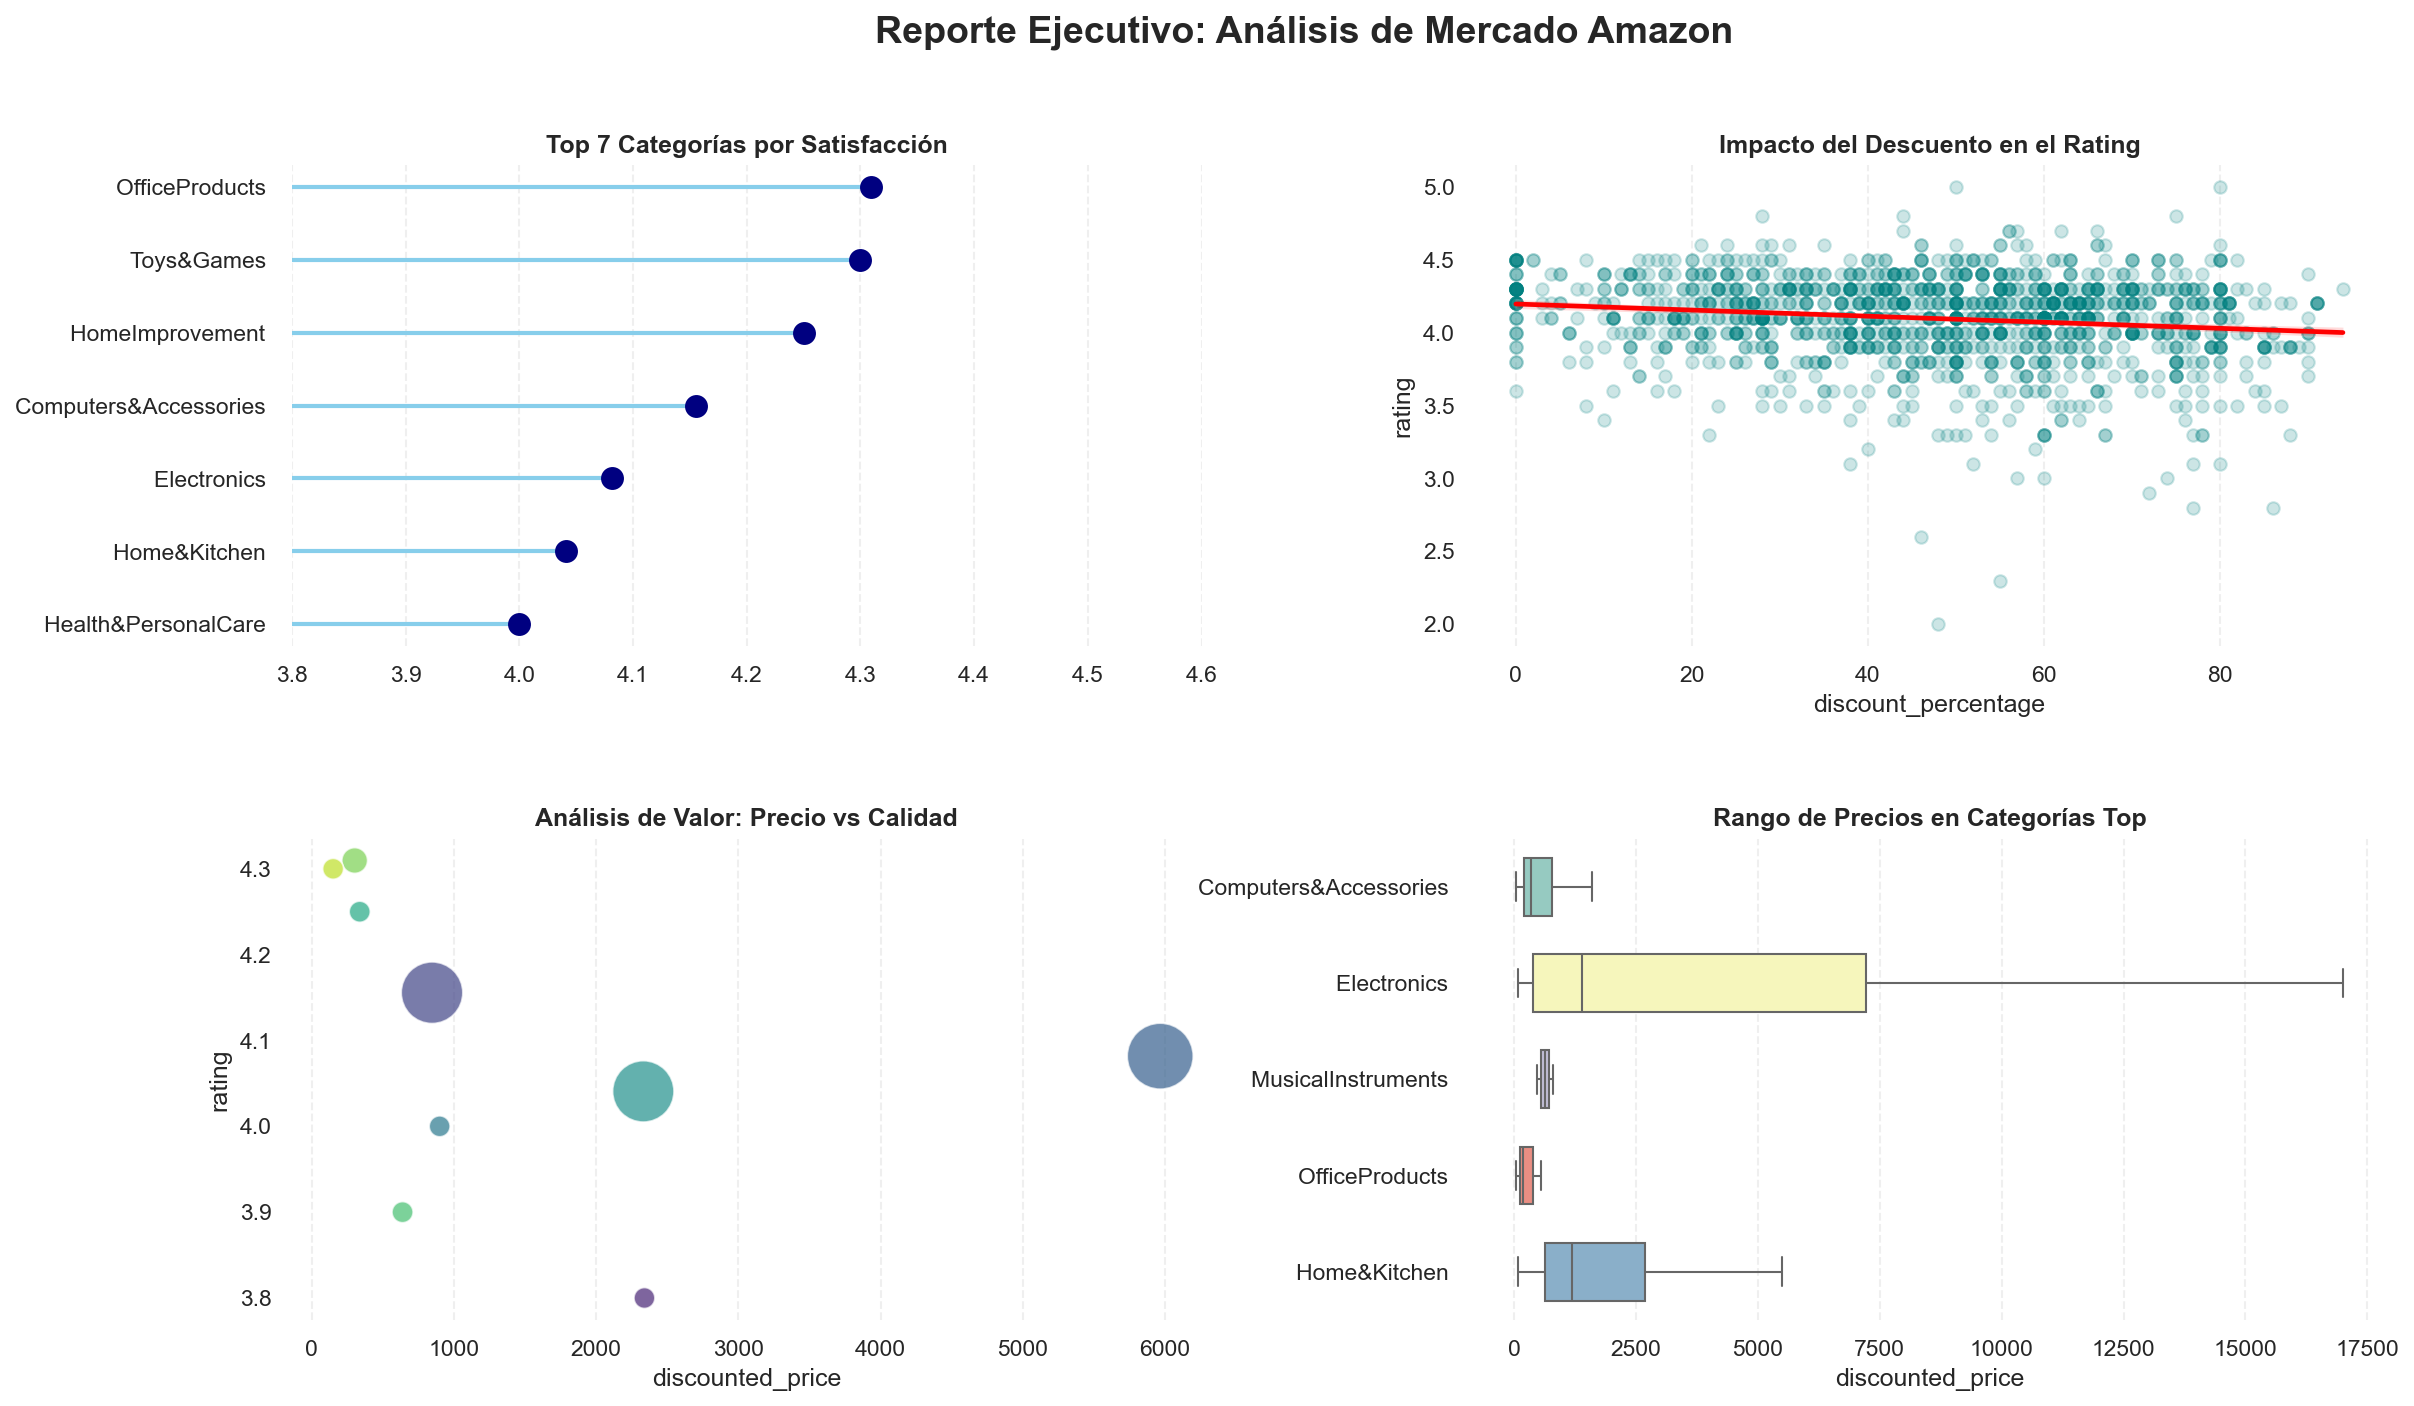

In [16]:
# --- CONFIGURACIÓN ESTÉTICA GLOBAL ---
sns.set_theme(style="white") # Fondo blanco limpio
plt.rcParams['figure.dpi'] = 150 # Alta resolución

# --- CREACIÓN DEL DASHBOARD (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Rating Promedio por Categoría (Lollipop elegante)
df_rating = df.groupby('main_category')['rating'].mean().sort_values().tail(7)
axes[0, 0].hlines(y=df_rating.index, xmin=3.5, xmax=df_rating.values, color='skyblue', linewidth=2)
axes[0, 0].plot(df_rating.values, df_rating.index, "o", markersize=10, color='navy')
axes[0, 0].set_title('Top 7 Categorías por Satisfacción', fontweight='bold')
axes[0, 0].set_xlim(3.8, 4.6)

# 2. Relación: % Descuento vs. Rating (Con densidad)
sns.regplot(data=df, x='discount_percentage', y='rating', ax=axes[0, 1], 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})
axes[0, 1].set_title('Impacto del Descuento en el Rating', fontweight='bold')

# 3. Categorías: Precio vs. Rating (Matriz de Burbujas)
cat_agg = df.groupby('main_category').agg({'discounted_price': 'mean', 'rating': 'mean', 'product_id': 'count'}).reset_index()
sns.scatterplot(data=cat_agg, x='discounted_price', y='rating', size='product_id', 
                hue='main_category', sizes=(100, 1000), alpha=0.7, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Análisis de Valor: Precio vs Calidad', fontweight='bold')
axes[1, 0].get_legend().remove() # Limpiar leyenda para que no estorbe

# 4. Distribución de Precios (Boxplot moderno)
top_5_cats = df['main_category'].value_counts().head(5).index
df_top = df[df['main_category'].isin(top_5_cats)]
sns.boxplot(data=df_top, x='discounted_price', y='main_category', ax=axes[1, 1], 
            palette="Set3", showfliers=False, width=0.6)
axes[1, 1].set_title('Rango de Precios en Categorías Top', fontweight='bold')
axes[1, 1].set_ylabel('')

# --- TOQUE FINAL: ELIMINAR BORDES ---
for ax in axes.flat:
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle('Reporte Ejecutivo: Análisis de Mercado Amazon', fontsize=18, fontweight='bold', y=0.98)
plt.savefig('dashboard_amazon.png', bbox_inches='tight', facecolor='white')
print("✅ Imagen 'dashboard_amazon.png' guardada. ¡Lista para tu post!")
plt.show()

In [17]:
df.to_csv('cleanedAmazon.csv',index=False)